In [1]:
import anndata as ad
import pandas as pd
import scanpy as sc
from pathlib import Path
import os
import sklearn
import scipy
import numpy as np
import sceleto2 as scl
import pickle
import glob
import os
import scrublet as scr
import matplotlib.pyplot as plt


sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, dpi_save=300, figsize=(5,5))
sc.settings.figdir = "./figures"
sc.settings.autosave = False
random_seed = 0

from datetime import date
TODAY = date.today()
print(TODAY)

/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-09-12


In [2]:
dataset = 'liu'

# 1. QC

In [3]:
#adata = sc.read_h5ad("/home/neuro_demo_research/repo/epilepsy_microglia_repo/notebooks/epilepsy_microglia/data/processed/galvao/galvao.h5ad")
adata = sc.read_h5ad(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}.h5ad")
adata

AnnData object with n_obs × n_vars = 20153934 × 33694
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia'

In [6]:
adata.var

,ensembl_id,highly_variable,means,dispersions,dispersions_norm,gene_symbol,mapping_status
ENSG00000243485,ENSG00000243485,False,5.024650e-04,9.197525,0.501363,MIR1302-2HG,mapped
ENSG00000237613,ENSG00000237613,False,1.000000e-12,NaN,NaN,FAM138A,mapped
ENSG00000186092,ENSG00000186092,False,1.000000e-12,NaN,NaN,OR4F5,mapped
ENSG00000238009,ENSG00000238009,False,9.514761e-03,8.894179,0.370082,NaN,unmapped
ENSG00000239945,ENSG00000239945,False,2.536121e-04,8.495118,0.197378,NaN,unmapped
...,...,...,...,...,...,...,...
ENSG00000277856,ENSG00000277856,False,1.000000e-12,NaN,NaN,NaN,unmapped
ENSG00000275063,ENSG00000275063,False,1.000000e-12,NaN,NaN,LOC102723407,mapped
ENSG00000271254,ENSG00000271254,False,3.479342e-02,8.976587,0.405746,LOC124905564,mapped
ENSG00000277475,ENSG00000277475,False,3.855330e-07,2.050271,-2.591797,NaN,unmapped


In [9]:
adata.var['gene_symbols'] = adata.var['gene_symbol'].copy()
adata.var.drop(columns=["gene_symbol"], inplace=True)

In [5]:
del adata
adata = sc.read_h5ad(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")
adata

AnnData object with n_obs × n_vars = 20153934 × 33694
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_symbol', 'mapping_status'
    uns: 'hvg', 'log1p'
    layers: 'counts'

In [16]:
adata

AnnData object with n_obs × n_vars = 20153934 × 33694
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mapping_status', 'gene_symbols'
    uns: 'hvg', 'log1p'
    layers: 'counts'

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}.h5ad")

In [21]:
adata = adata[
    :, adata.var["mapping_status"] == "mapped"
].copy()

In [22]:
adata

AnnData object with n_obs × n_vars = 20153934 × 26106
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mapping_status', 'gene_symbols'
    uns: 'hvg', 'log1p'
    layers: 'counts'

In [23]:
adata.var_names_make_unique()

adata.var["mt"] = adata.var['gene_symbols'].str.upper().str.startswith("MT-")
adata.var["ribo"] = adata.var['gene_symbols'].str.upper().str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var['gene_symbols'].str.upper().str.startswith(
    ("HBA", "HBB", "HBD", "HBE", "HBG", "HBM", "HBQ", "HBZ")
)

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    percent_top=[20],
    log1p=True,
)

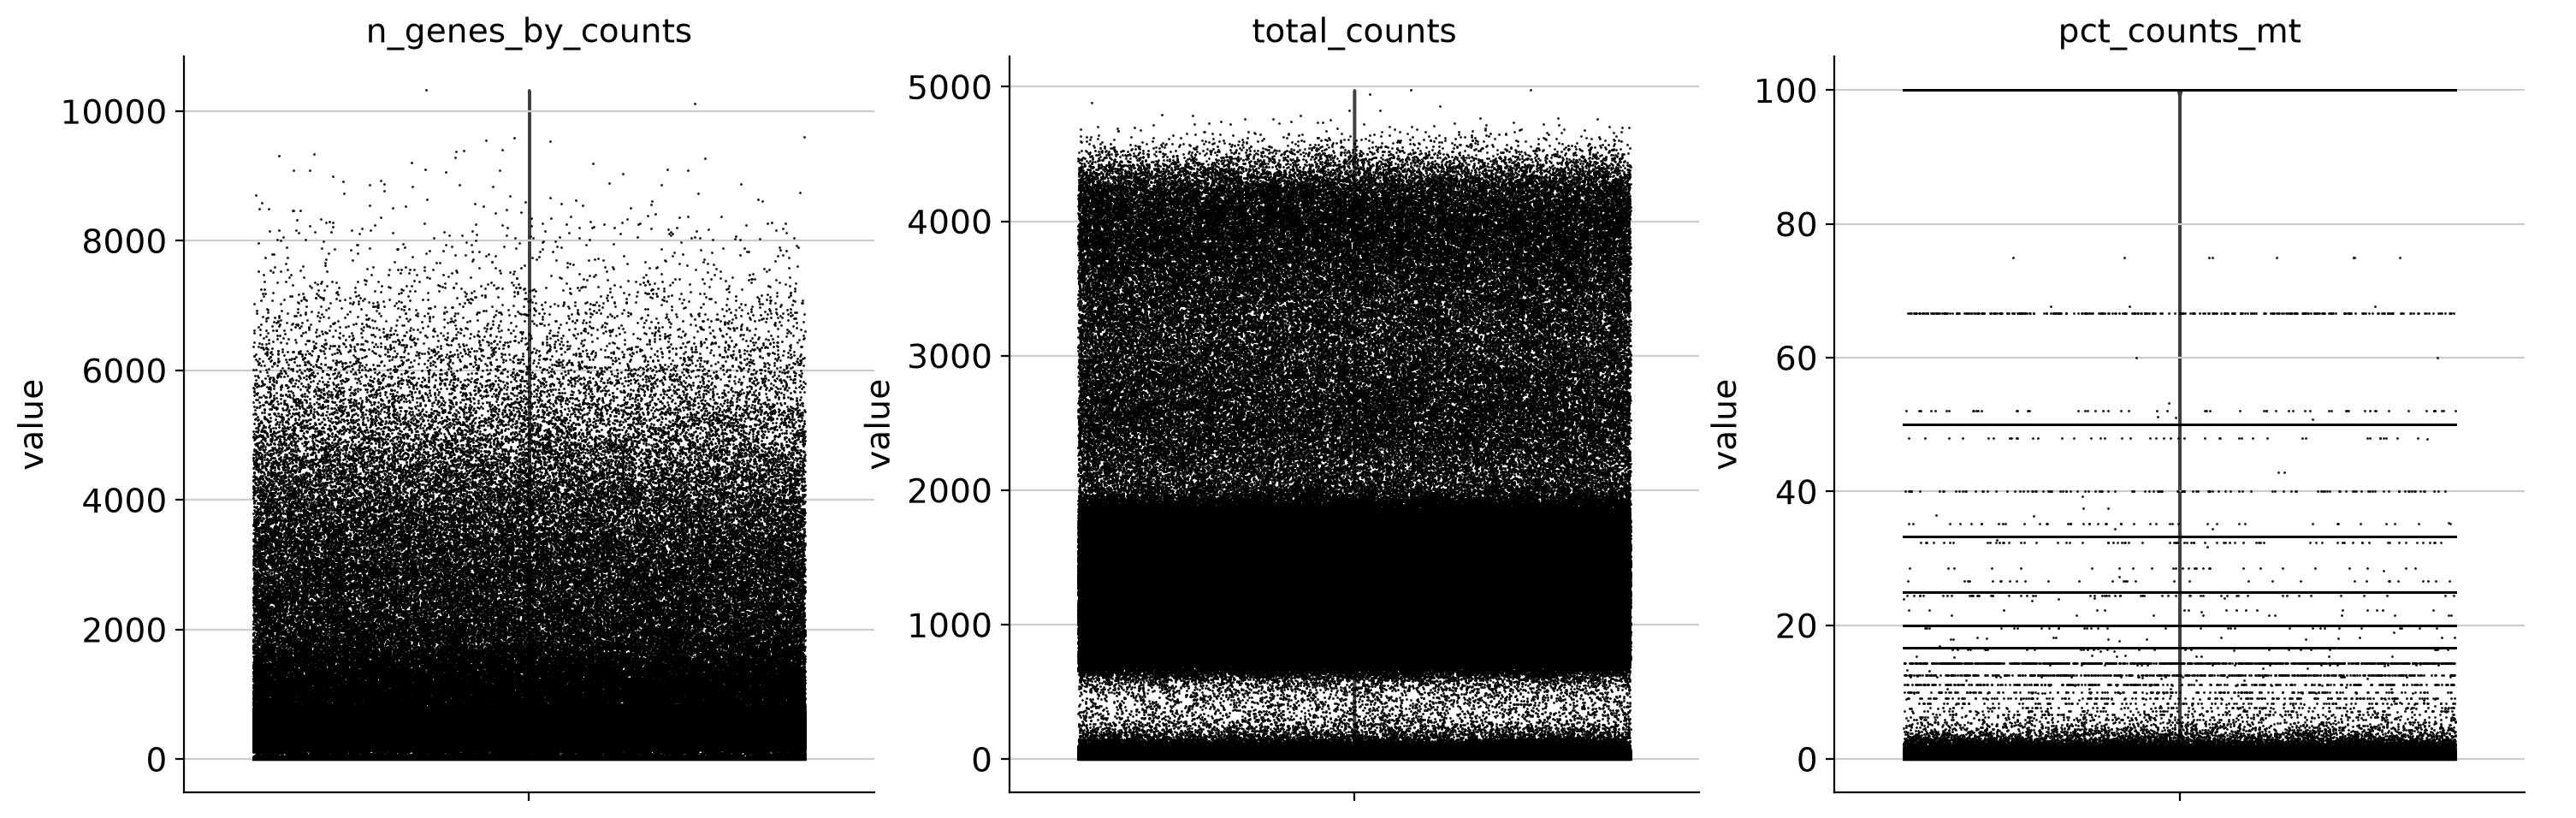

In [24]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [ ]:
plt.scatter(adata.obs['log1p_total_counts'], adata.obs['log1p_n_genes_by_counts'], c=adata.obs['pct_counts_mt'], s=0.01)
#plt.axvline(x=np.log1p(750), color='r', linestyle='--', linewidth=1) # min_counts
plt.axhline(y=np.log1p(300), color='r', linestyle='--', linewidth=1) # min_genes
#plt.axhline(y=np.log1p(7000), color='r', linestyle='--', linewidth=1) # max_genes
plt.xlabel('log1p_total_counts')
plt.ylabel('log1p_n_genes_by_counts')
plt.colorbar()
plt.show()

plt.scatter(adata.obs['n_genes_by_counts'], adata.obs['pct_counts_mt'], c=adata.obs['log1p_total_counts'], s=0.1)
plt.axvline(x=300, color='r', linestyle='--', linewidth=1) # min_genes
#plt.axvline(x=7000, color='r', linestyle='--', linewidth=1) # max_genes
plt.axhline(y=20, color='r', linestyle='--', linewidth=1) # max_mt
plt.xlabel('n_genes_by_counts')
plt.ylabel('pct_counts_mt')
plt.colorbar()
plt.show()

,sample_id,donor_id,total_counts,n_genes_by_counts
AAACCCAAGAAACACT-1-GSM8244661,Control-1_snRNA,Control-1,850.0,700
AAACCCAAGAAACCAT-1-GSM8244661,Control-1_snRNA,Control-1,2.0,2
AAACCCAAGAAACTAC-1-GSM8244661,Control-1_snRNA,Control-1,0.0,0
AAACCCAAGAAACTCA-1-GSM8244661,Control-1_snRNA,Control-1,2.0,2
AAACCCAAGAAACTGC-1-GSM8244661,Control-1_snRNA,Control-1,0.0,0


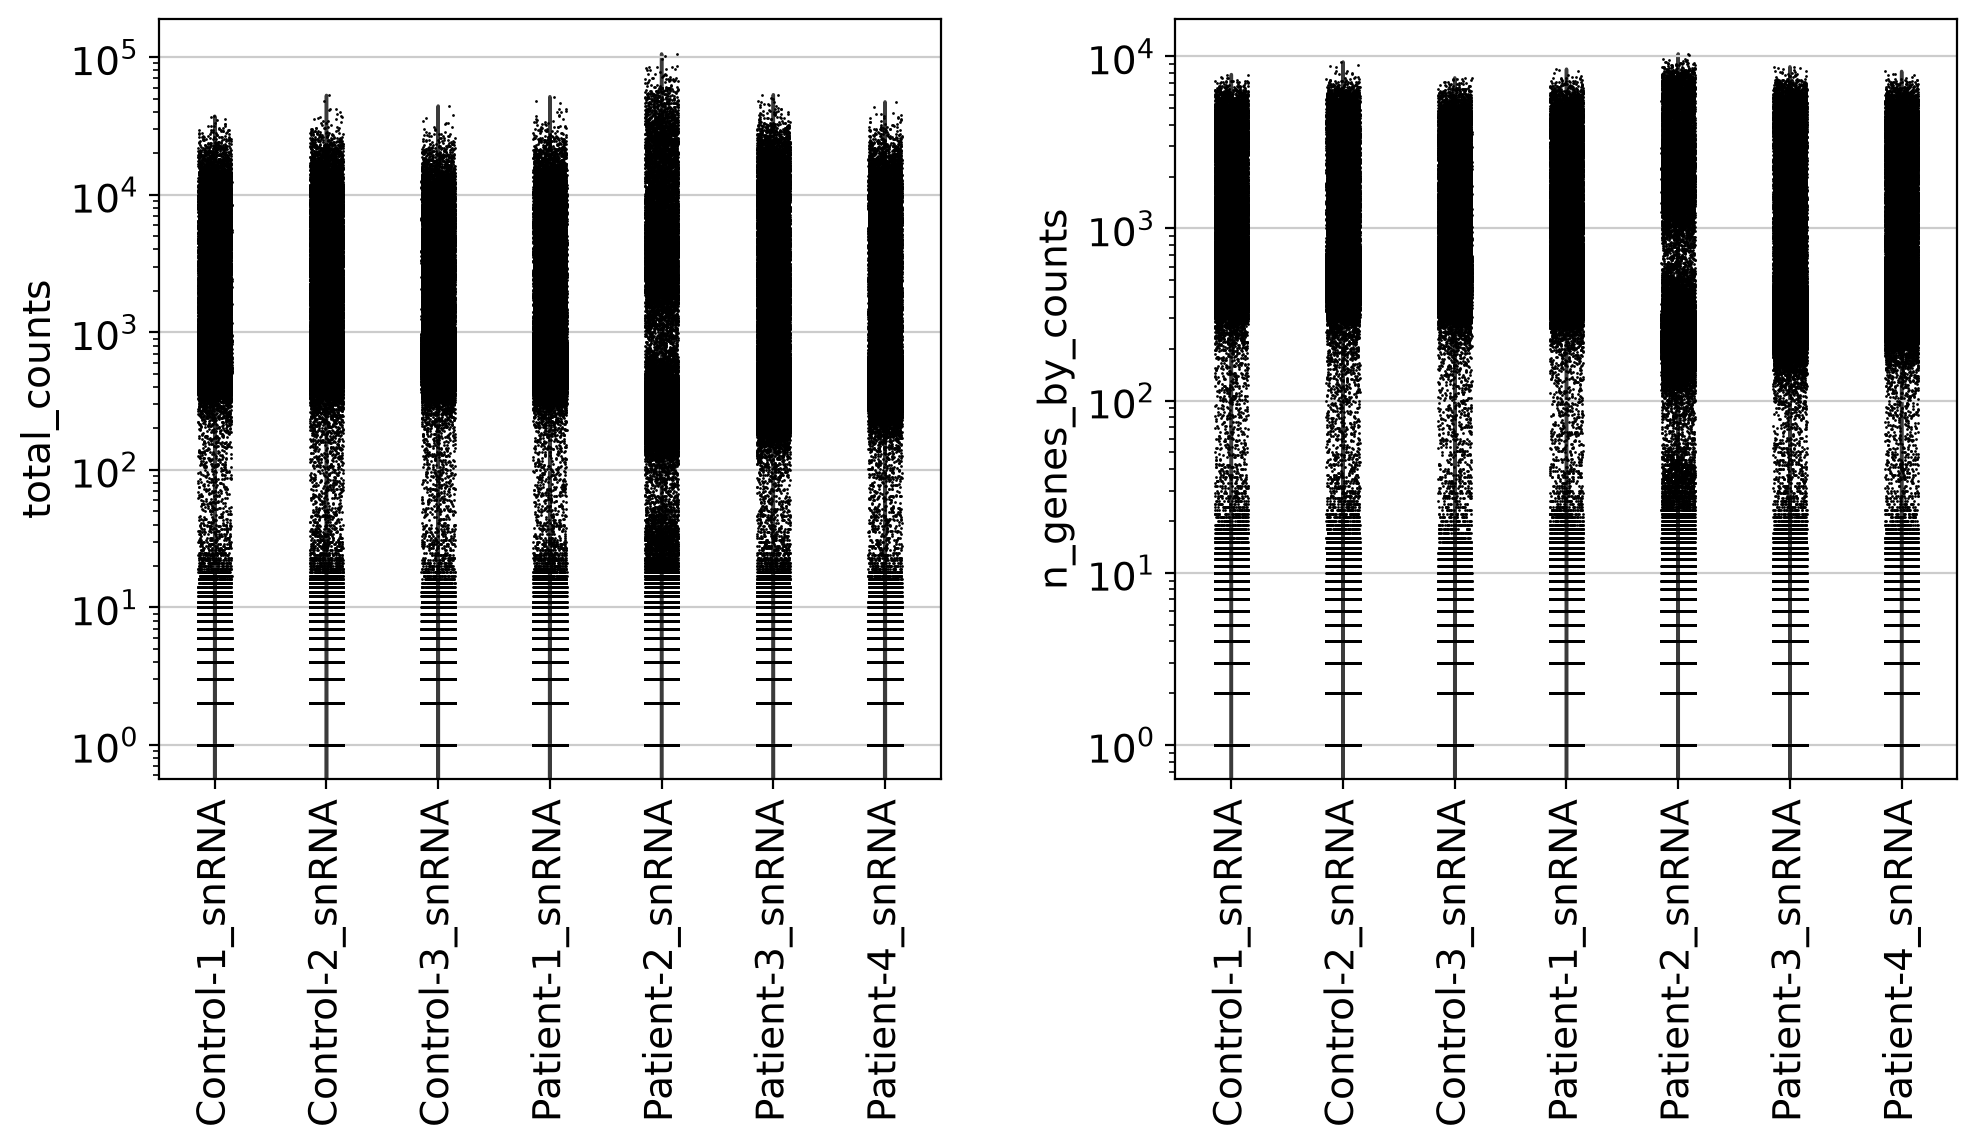

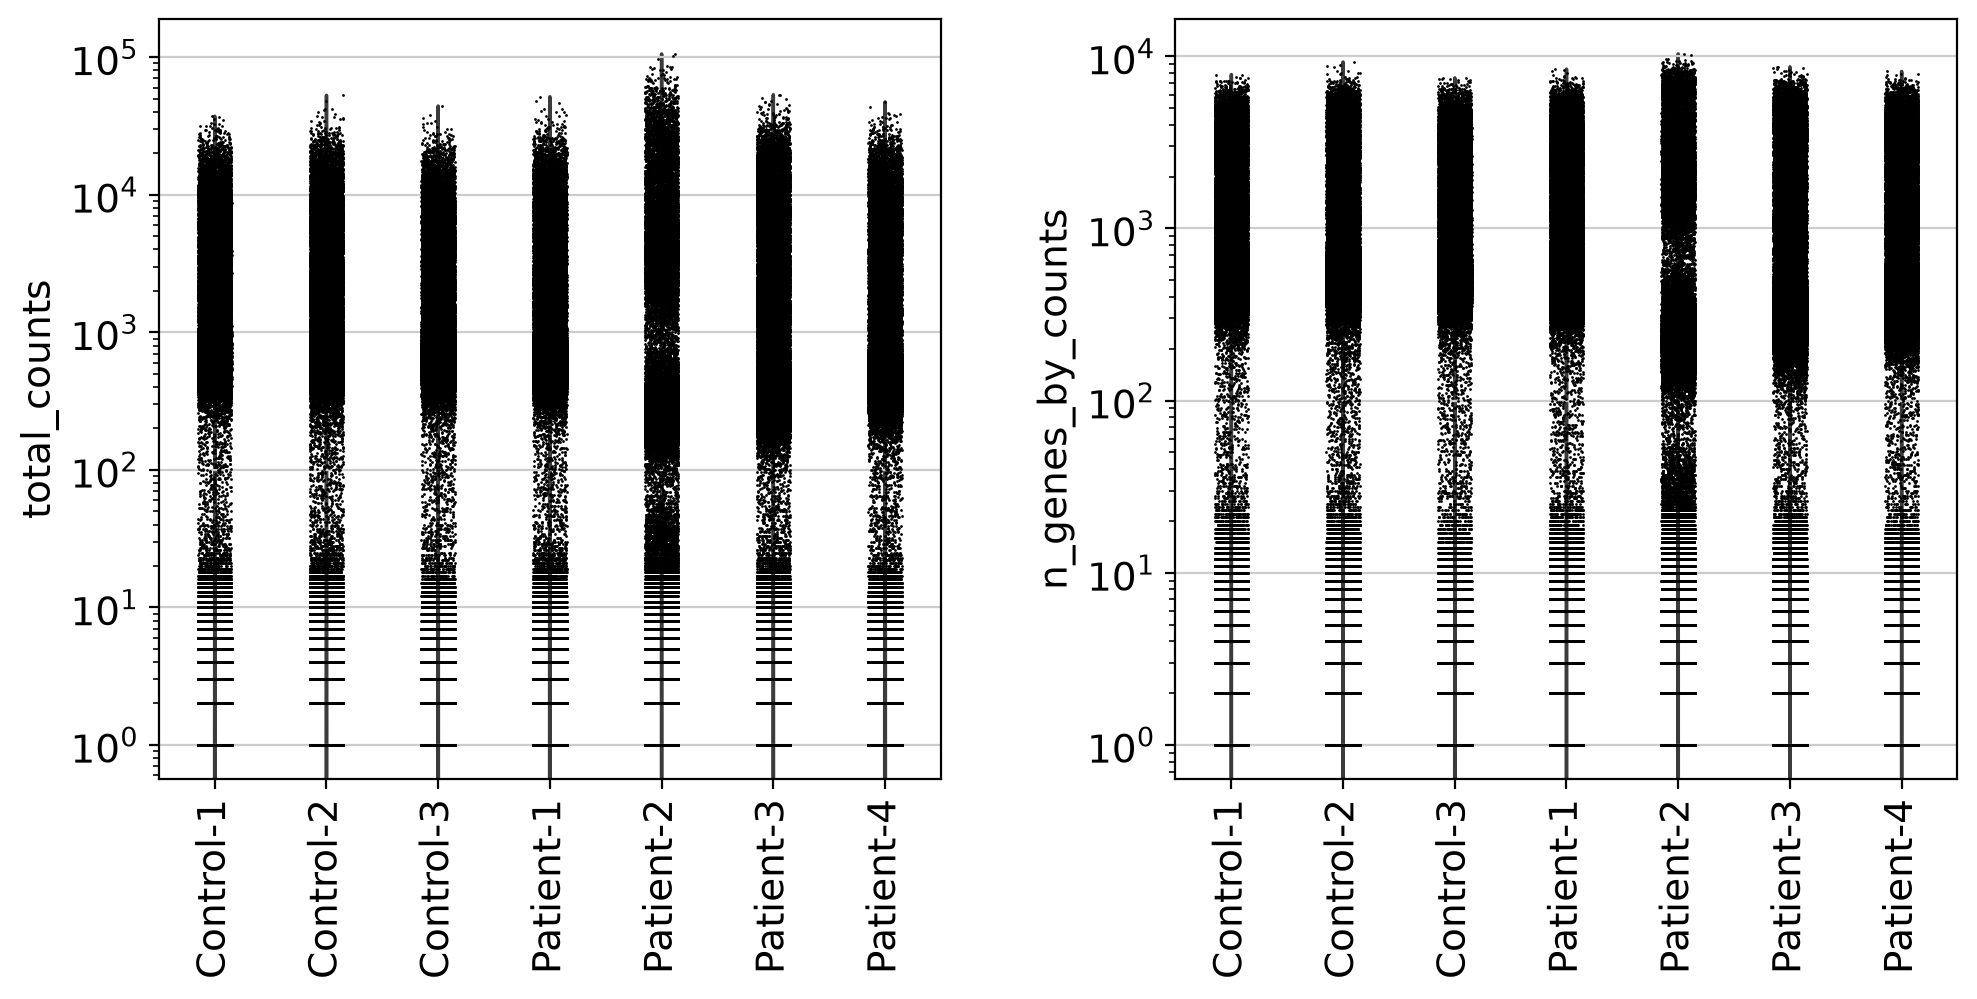

In [25]:
# check donor/sample-level qc metrics

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# Use the raw-count layer if present; otherwise use adata.X.
count_layer = "counts" if "counts" in adata.layers else None

sc.pp.calculate_qc_metrics(
    adata,
    layer=count_layer,
    inplace=True,
    log1p=False,
)

# Confirm these exist before plotting.
display(
    adata.obs[
        ["sample_id", "donor_id", "total_counts", "n_genes_by_counts"]
    ].head()
)

for groupby in ["sample_id", "donor_id"]:
    if groupby not in adata.obs.columns:
        print(f"Skipping {groupby}: column not found.")
        continue

    sc.pl.violin(
        adata,
        keys=["total_counts", "n_genes_by_counts"],
        groupby=groupby,
        layer=count_layer,
        log=True,          # easier to see the low-count nuclear tail
        jitter=0.15,
        rotation=90,
        multi_panel=True,
        show=True,
    )

In [ ]:
cutoffs = pd.DataFrame(
    {
        "counts≥500": adata.obs["total_counts"] >= 500,
        "counts≥1000": adata.obs["total_counts"] >= 1000,
        "counts≥2000": adata.obs["total_counts"] >= 2000,
        "genes≥250": adata.obs["n_genes_by_counts"] >= 250,
        "genes≥500": adata.obs["n_genes_by_counts"] >= 500,
    },
    index=adata.obs_names,
)

retention_by_sample = (
    cutoffs
    .join(adata.obs["sample_id"])
    .groupby("sample_id", observed=True)
    .mean()
    .mul(100)
    .round(1)
)

display(retention_by_sample)

,counts≥500,counts≥1000,counts≥2000,genes≥250,genes≥500
sample_id,,,,,
Control-1_snRNA,2.3,0.5,0.3,2.7,1.7
Control-2_snRNA,2.3,0.5,0.4,2.7,1.7
Control-3_snRNA,2.7,0.6,0.4,3.1,2.0
Patient-1_snRNA,2.2,0.4,0.3,2.8,1.5
Patient-2_snRNA,0.5,0.4,0.4,1.4,0.5
Patient-3_snRNA,0.6,0.5,0.4,2.3,0.6
Patient-4_snRNA,1.3,0.5,0.4,3.0,0.8


: 

In [ ]:
# doublet detection

scrub = scr.Scrublet(adata.X)
scores, predicted = scrub.scrub_doublets(verbose=False)

adata.obs["doublet_scores"] = scores
adata.obs["predicted_doublets"] = predicted

print(adata.obs["predicted_doublets"].value_counts())

/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/scrublet/helper_functions.py:321: RuntimeWarning: divide by zero encountered in divide
  w.setdiag(float(target_total) / tots_use)
/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/scrublet/helper_functions.py:252: RuntimeWarning: invalid value encountered in sqrt
  CV_input = np.sqrt(b);


In [ ]:
#sc.pp.filter_cells(adata, min_counts=500) 
sc.pp.filter_cells(adata, min_genes=300)
#sc.pp.filter_cells(adata, max_genes=7000) 
adata = adata[adata.obs['pct_counts_mt'] < 20, :] # 20% 이상의 mitochondria 분율을 가진 Sample 제외 (doublet 일 수 있음)

In [ ]:
adata = adata[~adata.obs["predicted_doublets"]].copy()

In [ ]:
adata

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 2. Preprocess

In [ ]:
adata.layers['counts'] = adata.X.copy()

In [ ]:
print(adata.layers['counts'].max())
print(adata.layers['counts'].min())

In [ ]:
# normalization

print('before log1p norm')
print('max: ', np.max(adata.X))
print('min: ', np.min(adata.X))
print('mean: ', np.mean(adata.X))

adata.var_names_make_unique()
adata.obs_names_make_unique()

# Normalization : Sample 에서 세포 합이 모두 100,00 이 되도록 함 (Sample 간의 비교를 위해)
sc.pp.normalize_total(adata, target_sum=1e4)

# Matrix 가 잘 정규화 되었는지 확인
adata.X.sum(axis=1)

# Logarithmize
sc.pp.log1p(adata)
adata.raw = adata
print('after log1p norm')
print('max: ', np.max(adata.X))
print('min: ', np.min(adata.X))
print('mean: ', np.mean(adata.X))

In [ ]:
# HVG (Highly variable genes) : adata 에서 어떤 Gene 들이 많이 차이가 나는지 확인
sc.pp.highly_variable_genes(adata) # adata 에서 HVG 에 해당하는 Gene 갯수를 확인
sc.pl.highly_variable_genes(adata)
print(f"detected {np.sum(adata.var['highly_variable'])} highly variable genes")

sc.pp.scale(adata, max_value=10)

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 3. Feature Selecetion

In [ ]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata)

In [ ]:
sc.pl.pca(adata, color = 'donor_id')

In [ ]:
sc.pl.pca(adata, color = 'sample_id')

In [ ]:
# without batch correction

sc.pp.neighbors(adata, use_rep = 'X_pca', n_pcs = 20)
sc.tl.umap(adata)
sc.pl.umap(adata, color = 'donor_id', save=f"_{TODAY}_{dataset}_donor_xharmony_npcs=20.png")

In [ ]:
sc.pl.umap(adata, color = 'sample_id', save=f"_{TODAY}_{dataset}_sample_xharmony_npcs=20.png")

In [ ]:
import harmonypy as hm

ho = hm.run_harmony(
    adata.obsm["X_pca"].astype(np.float64),
    adata.obs,
    "sample_id",
    max_iter_harmony=50
)

print(ho.Z_corr.shape)
adata.obsm["X_pca_harmony"] = np.asarray(ho.Z_corr)

In [ ]:
# with batch correction

sc.pp.neighbors(adata, use_rep = 'X_pca_harmony', n_pcs = 20)
sc.tl.umap(adata)
sc.pl.umap(adata, color = 'donor_id', save=f"_{TODAY}_{dataset}_donor_harmony_npcs=20.png")

In [ ]:
sc.pl.umap(adata, color = 'sample_id', save=f"_{TODAY}_{dataset}_sample_harmony_npcs=20.png")

# 4. Clustering

In [ ]:
sc.tl.leiden(adata, resolution = 0.5, key_added='leiden_05')
sc.tl.leiden(adata, resolution = 1.0, key_added='leiden_10')

In [ ]:
scl.us(adata, 'leiden_05,leiden_10')

In [ ]:
sc.tl.rank_genes_groups(adata, groupby='leiden_05', method='wilcoxon', use_raw=False)

In [ ]:
adata.var_names = adata.var['gene_symbols'].copy()
adata.var_names_make_unique()

print(adata.var_names[:10])
print(adata.var_names.is_unique)

In [ ]:
sc.pl.rank_genes_groups(adata, ncols = 6)

In [ ]:
raw = adata.raw.to_adata()

raw.var_names = raw.var['gene_symbols'].astype(str)
raw.var_names_make_unique()

adata.raw = raw

In [ ]:
adata.raw.var.index.name = "feature_id"
adata.var.index.name = "feature_id"

if adata.raw is not None:
    adata.raw.var.index.name = "feature_id"

In [ ]:
gene_to_id = dict(zip(odata.var["gene_symbols"], odata.var_names))

adata.var["source_gene_id"] = adata.var["gene_symbols"].map(gene_to_id)

print(adata.var[["gene_symbols", "source_gene_id"]].head())
print("Unmapped:", adata.var["source_gene_id"].isna().sum())

In [ ]:
M = scl.markers.marker(adata,'leiden_05')
M.plot_marker()

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 5. Lv.1 Annotation

In [ ]:
markers_full = {
    "Microglia": [
        "P2RY12", "P2RY13", "TMEM119", "CX3CR1",
        "C1QA", "C1QB", "C1QC", "GPR34", "CSF1R"
    ],
    "Macrophage_MDM": [
        "FCGR3A", "LILRB1", "LILRB2", "CTSD",
        "CTSB", "LGALS3", "APOE", "SPP1"
    ],
    "Lymphocyte": [
        "CD3D", "CD3E", "TRBC1", "TRBC2",
        "SKAP1", "CD96", "CCL4", "NKG7"
    ],
    "Astrocyte": [
        "AQP4", "SLC1A2", "SLC1A3", "GFAP", "ALDH1L1"
    ],
    "Oligodendrocyte": [
        "PLP1", "MBP", "MOG", "MAG", "MOBP"
    ],
    "OPC": [
        "PDGFRA", "CSPG4", "VCAN", "OLIG1", "OLIG2"
    ],
    "Endothelial": [
        "CLDN5", "FLT1", "PECAM1", "VWF", "EMCN"
    ],
    "Pericyte": [
        "RGS5", "ABCC9", "PDGFRB", "CSPG4", "MCAM"
    ],
}

gene_set = set(adata.var["gene_symbols"].dropna())

markers = {
    celltype: [gene for gene in genes if gene in gene_set]
    for celltype, genes in markers_full.items()
}

In [ ]:
umap_markers = [
    # Microglia
    "P2RY12", "TMEM119", "C1QA",

    # Macrophage / MDM
    "FCGR3A", "LGALS3", "SPP1",

    # Lymphocyte
    "CD3D", "NKG7",

    # Astrocyte
    "AQP4", "SLC1A2",

    # Oligodendrocyte
    "PLP1", "MOBP",

    # OPC
    "PDGFRA", "VCAN",

    # Endothelial
    "CLDN5", "VWF",

    # Pericyte
    "RGS5", "PDGFRB",
]

In [ ]:
sc.pl.dotplot(
    adata,
    markers,
    groupby="leiden_05",
    standard_scale="var",
    dendrogram=False,
    figsize=(max(12, len(markers) * 0.35), 6),
)

In [ ]:
scl.us(adata, umap_markers)

In [ ]:
lv1_map = {
    "0": "Microglia",
    "1": "Microglia",
    "2": "Microglia",
    "3": "Microglia",
    "4": "Microglia",
    "5": "Lymphocyte",
    "6": "Macrophage/MDM",
    "7": "Pericyte/Endothelial",
    "8": "Pericyte/Endothelial",
    "9": "Macrophage/MDM",
    "10": "Oligodendrocyte",
    "11": "Ribosomal",
    "12": "Lymphocyte",
    "13": "lowquality",
}

adata.obs["celltype_lv1"] = (
    adata.obs["leiden_05"]
    .astype(str)
    .map(lv1_map)
    .astype("category")
)

In [ ]:
scl.us(adata, 'leiden_05,celltype_lv1')

In [ ]:
odata = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/kumar/kumar.h5ad")
odata.var

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 6. Microglia Lv. 2 annotation

In [ ]:
print(adata)

mdata = adata[
    adata.obs["celltype_lv1"].isin(["Microglia", "Macrophage/MDM"])
].copy()

In [ ]:
mdata

In [ ]:
mdata.X = mdata.layers['counts'].copy()
print(mdata.X.max(), mdata.X.min())

In [ ]:
# preprocess
sc.pp.normalize_total(mdata)
sc.pp.log1p(mdata)
sc.pp.highly_variable_genes(mdata)
sc.pp.scale(mdata)

In [ ]:
# feature selection
sc.tl.pca(mdata)
sc.pl.pca_variance_ratio(mdata)

In [ ]:
sc.pp.neighbors(mdata, use_rep = 'X_pca', n_pcs=20)
sc.tl.umap(mdata)
scl.us(mdata, 'donor_id,sample_id')

In [ ]:
#mdata.obs.drop(columns=["leiden_05", "leiden_10"], inplace=True)
#mdata.uns.pop("cdm_leiden_05", None)
for key in ["leiden_05", "leiden_10", "leiden_05_colors", "leiden_10_colors"]:
    mdata.uns.pop(key, None)

In [ ]:
mdata

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_mg.h5ad")